In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("mmi711_outputs_multilabel")

data = np.load(OUTPUT_DIR / "mmi711_multilabel_variable_length_datasets.npz")

with open(OUTPUT_DIR / "dataset_config_multilabel_variable_lengths.json", "r") as f:
    config = json.load(f)

LENGTHS = config["lengths"]
EVENT_LABELS = config["event_labels"]

meta_all = pd.read_csv(OUTPUT_DIR / "meta_all_multilabel_variable_lengths.csv")

print("Lengths:", LENGTHS)
print("Event labels:", EVENT_LABELS)
print("Metadata shape:", meta_all.shape)
print("Available arrays:", data.files[:5], "...")

Lengths: [400, 800, 1200]
Event labels: ['mean_shift', 'variance_shift', 'trend_shift', 'point_anomaly', 'collective_anomaly']
Metadata shape: (7680, 11)
Available arrays: ['X_train_L400', 'Y_train_L400', 'X_train_L800', 'Y_train_L800', 'X_train_L1200'] ...


In [2]:
def clean_numpy_wrappers(text):
    """
    Removes wrappers like np.int64(123), np.float64(1.2), array([1, 2])
    enough for regex-based integer extraction.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # np.int64(123) -> 123, np.float64(1.2) -> 1.2
    text = re.sub(r"np\.(?:int\d+|float\d+)\(([^()]*)\)", r"\1", text)

    # array([1, 2]) -> [1, 2]
    text = re.sub(r"array\((\[[^\]]*\])\)", r"\1", text)

    return text


def extract_int_list_from_bracket_text(text):
    """
    Extracts integers from a bracket-like text such as:
        [12, 30]
        [np.int64(12), np.int64(30)]
        array([12, 30])
    """
    text = clean_numpy_wrappers(text)
    nums = re.findall(r"[-+]?\d+", text)
    return [int(x) for x in nums]


def extract_key_list_near_subtype(event_text, subtype, key):
    """
    Extracts integer list for a given key near a specific subtype.

    Example:
        subtype='mean_shift', key='shift_indices'
        subtype='collective', key='starts'
    """
    event_text = clean_numpy_wrappers(event_text)

    # Find a chunk starting at the subtype and ending later.
    subtype_pattern = rf"['\"]subtype['\"]\s*:\s*['\"]{re.escape(subtype)}['\"]"
    subtype_match = re.search(subtype_pattern, event_text)

    if subtype_match is None:
        return []

    chunk = event_text[subtype_match.start():]

    # Find key: [...]
    key_pattern = rf"['\"]{re.escape(key)}['\"]\s*:\s*(\[[^\]]*\])"
    key_match = re.search(key_pattern, chunk)

    if key_match is None:
        return []

    return extract_int_list_from_bracket_text(key_match.group(1))


def extract_point_anomaly_indices(event_text):
    """
    Extracts point anomaly indices from single or multiple point anomaly metadata.
    """
    event_text = clean_numpy_wrappers(event_text)

    if "point_anomaly" not in event_text and "single_point" not in event_text and "multiple_point" not in event_text:
        return []

    pattern = r"['\"]anomaly_indices['\"]\s*:\s*(\[[^\]]*\])"
    match = re.search(pattern, event_text)

    if match is None:
        return []

    return extract_int_list_from_bracket_text(match.group(1))


def extract_collective_intervals(event_text):
    """
    Extracts collective anomaly intervals as (start, end) pairs.
    """
    starts = extract_key_list_near_subtype(event_text, "collective", "starts")
    ends = extract_key_list_near_subtype(event_text, "collective", "ends")

    if len(starts) == 0 or len(ends) == 0:
        return []

    n_pairs = min(len(starts), len(ends))
    return list(zip(starts[:n_pairs], ends[:n_pairs]))


def extract_shift_indices(event_text, shift_subtype):
    """
    Extracts shift indices for one shift type.
    shift_subtype should be:
        mean_shift
        variance_shift
        trend_shift
    """
    return extract_key_list_near_subtype(event_text, shift_subtype, "shift_indices")

In [3]:
def make_location_label_matrix_from_row(row, length, event_labels):
    """
    Converts one metadata row into a time-step label matrix.

    Output shape:
        (length, number_of_event_labels)

    Label meaning:
        mean_shift / variance_shift / trend_shift:
            0 = before shift
            1 = regime after first shift
            2 = regime after second shift
            3 = regime after third shift
            ...

        point_anomaly:
            1 only at anomaly indices

        collective_anomaly:
            1 during anomaly intervals
    """
    event_text = row.get("event_infos", "")
    event_text = "" if pd.isna(event_text) else str(event_text)

    Y_loc = np.zeros((length, len(event_labels)), dtype=np.int16)

    label_to_col = {label: i for i, label in enumerate(event_labels)}

    # ----------------------------
    # Shift labels: regime encoding
    # ----------------------------
    for shift_label in ["mean_shift", "variance_shift", "trend_shift"]:
        if shift_label not in label_to_col:
            continue

        col = label_to_col[shift_label]
        shift_indices = extract_shift_indices(event_text, shift_label)
        shift_indices = sorted([idx for idx in shift_indices if 0 <= idx < length])

        for regime_id, start_idx in enumerate(shift_indices, start=1):
            Y_loc[start_idx:, col] = regime_id

    # ----------------------------
    # Point anomaly labels: binary
    # ----------------------------
    if "point_anomaly" in label_to_col:
        col = label_to_col["point_anomaly"]
        point_indices = extract_point_anomaly_indices(event_text)
        point_indices = [idx for idx in point_indices if 0 <= idx < length]

        if len(point_indices) > 0:
            Y_loc[point_indices, col] = 1

    # ----------------------------
    # Collective anomaly labels: binary interval
    # ----------------------------
    if "collective_anomaly" in label_to_col:
        col = label_to_col["collective_anomaly"]
        intervals = extract_collective_intervals(event_text)

        for start, end in intervals:
            start = max(0, min(length, start))
            end = max(0, min(length, end))

            if end > start:
                Y_loc[start:end, col] = 1

    return Y_loc

In [4]:
location_arrays_to_save = {}

for dataset_name in ["train", "val", "ood_params", "ood_background"]:
    for length in LENGTHS:
        print(f"Converting dataset={dataset_name}, length={length}")

        meta_subset = meta_all[
            (meta_all["dataset"] == dataset_name) &
            (meta_all["length"] == length)
        ].reset_index(drop=True)

        X_key = f"X_{dataset_name}_L{length}"
        Y_key = f"Y_{dataset_name}_L{length}"

        X_arr = data[X_key]
        Y_event = data[Y_key]

        if len(meta_subset) != X_arr.shape[0]:
            raise ValueError(
                f"Metadata length mismatch for {dataset_name}, length={length}. "
                f"meta={len(meta_subset)}, X={X_arr.shape[0]}"
            )

        Y_loc = np.stack([
            make_location_label_matrix_from_row(
                row=meta_subset.iloc[i],
                length=length,
                event_labels=EVENT_LABELS
            )
            for i in range(len(meta_subset))
        ])

        location_arrays_to_save[f"Yloc_{dataset_name}_L{length}"] = Y_loc

        print("  X shape:    ", X_arr.shape)
        print("  Y_event:    ", Y_event.shape)
        print("  Y_location: ", Y_loc.shape)
        print("  max label per event:", Y_loc.reshape(-1, len(EVENT_LABELS)).max(axis=0))

Converting dataset=train, length=400
  X shape:     (1600, 400)
  Y_event:     (1600, 5)
  Y_location:  (1600, 400, 5)
  max label per event: [2 2 2 1 1]
Converting dataset=train, length=800
  X shape:     (1600, 800)
  Y_event:     (1600, 5)
  Y_location:  (1600, 800, 5)
  max label per event: [2 2 2 1 1]
Converting dataset=train, length=1200
  X shape:     (1600, 1200)
  Y_event:     (1600, 5)
  Y_location:  (1600, 1200, 5)
  max label per event: [2 2 2 1 1]
Converting dataset=val, length=400
  X shape:     (320, 400)
  Y_event:     (320, 5)
  Y_location:  (320, 400, 5)
  max label per event: [2 2 2 1 1]
Converting dataset=val, length=800
  X shape:     (320, 800)
  Y_event:     (320, 5)
  Y_location:  (320, 800, 5)
  max label per event: [2 2 2 1 1]
Converting dataset=val, length=1200
  X shape:     (320, 1200)
  Y_event:     (320, 5)
  Y_location:  (320, 1200, 5)
  max label per event: [2 2 2 1 1]
Converting dataset=ood_params, length=400
  X shape:     (320, 400)
  Y_event:     (3

In [5]:
np.savez_compressed(
    OUTPUT_DIR / "mmi711_sequence_location_labels.npz",
    **location_arrays_to_save
)

location_config = {
    "label_format": "sequence_level_location_labels",
    "event_labels": EVENT_LABELS,
    "shift_label_meaning": {
        "0": "before any shift of this type",
        "1": "after first shift of this type",
        "2": "after second shift of this type",
        "3": "after third shift of this type"
    },
    "anomaly_label_meaning": {
        "0": "normal point for this anomaly type",
        "1": "point belongs to anomaly"
    },
    "shape": "Each Yloc array has shape (num_samples, sequence_length, num_event_labels)."
}

with open(OUTPUT_DIR / "sequence_location_label_config.json", "w") as f:
    json.dump(location_config, f, indent=4)

print("Saved sequence location labels.")
print("File:", OUTPUT_DIR / "mmi711_sequence_location_labels.npz")

Saved sequence location labels.
File: mmi711_outputs_multilabel\mmi711_sequence_location_labels.npz


In [6]:
loc_data = np.load(OUTPUT_DIR / "mmi711_sequence_location_labels.npz")

for key in sorted(loc_data.files):
    Yloc = loc_data[key]

    print("\n", key)
    print("shape:", Yloc.shape)

    flat = Yloc.reshape(-1, len(EVENT_LABELS))

    for i, label in enumerate(EVENT_LABELS):
        unique_vals, counts = np.unique(flat[:, i], return_counts=True)
        summary = dict(zip(unique_vals.tolist(), counts.tolist()))
        print(f"  {label:22s}: {summary}")


 Yloc_ood_background_L1200
shape: (320, 1200, 5)
  mean_shift            : {0: 317563, 1: 55113, 2: 11324}
  variance_shift        : {0: 314811, 1: 56960, 2: 12229}
  trend_shift           : {0: 319242, 1: 51839, 2: 12919}
  point_anomaly         : {0: 383949, 1: 51}
  collective_anomaly    : {0: 372927, 1: 11073}

 Yloc_ood_background_L400
shape: (320, 400, 5)
  mean_shift            : {0: 106570, 1: 17692, 2: 3738}
  variance_shift        : {0: 106353, 1: 17479, 2: 4168}
  trend_shift           : {0: 105683, 1: 19034, 2: 3283}
  point_anomaly         : {0: 127944, 1: 56}
  collective_anomaly    : {0: 124459, 1: 3541}

 Yloc_ood_background_L800
shape: (320, 800, 5)
  mean_shift            : {0: 213846, 1: 37942, 2: 4212}
  variance_shift        : {0: 211917, 1: 39756, 2: 4327}
  trend_shift           : {0: 213870, 1: 34049, 2: 8081}
  point_anomaly         : {0: 255959, 1: 41}
  collective_anomaly    : {0: 248755, 1: 7245}

 Yloc_ood_params_L1200
shape: (320, 1200, 5)
  mean_shift   

Scenario: trend_shift+point_anomaly
Scenario group: shift_anomaly
Background: linear
Active event labels: ['trend_shift', 'point_anomaly']
event_infos: [{'type': 'structural_break', 'subtype': 'trend_shift', 'num_breaks': 1, 'location': 'middle', 'shift_indices': [232], 'shift_types': ['direction_and_magnitude_change'], 'wrapper_event_label': 'trend_shift', 'linear_info_used': {'slope': np.float64(0.0038119426511908413), 'intercept': -0.08216052464407075}}, {'type': 'anomaly', 'subtype': 'single_point', 'num_anomalies': 1, 'anomaly_indices': array([282]), 'location': None, 'point_anomaly_variant': 'single_point', 'wrapper_event_label': 'point_anomaly'}]


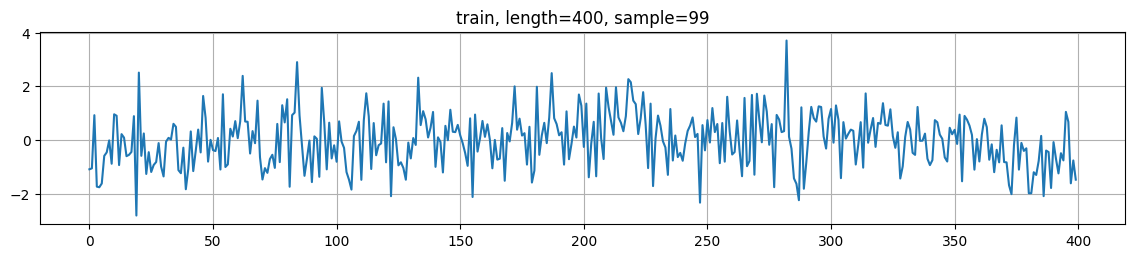

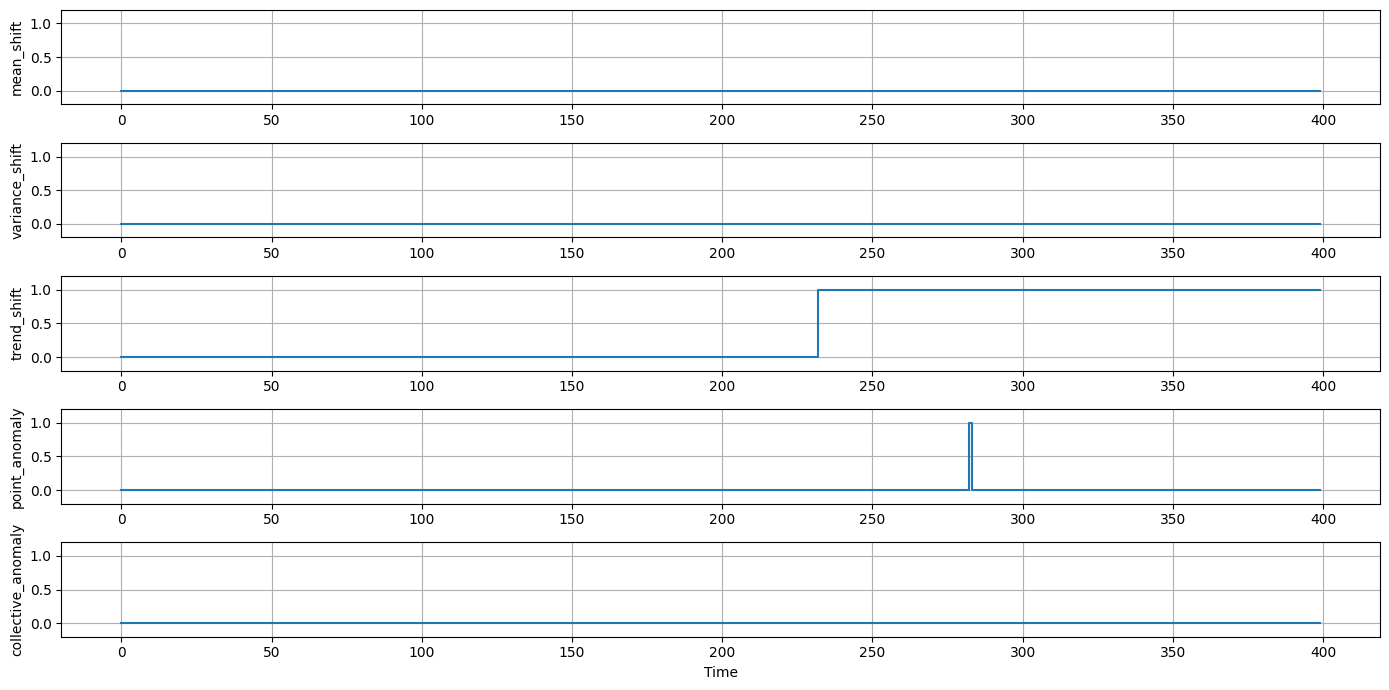

In [9]:
def plot_series_with_location_labels(dataset_name, length, sample_idx):
    X = data[f"X_{dataset_name}_L{length}"]
    Y_event = data[f"Y_{dataset_name}_L{length}"]
    Yloc = loc_data[f"Yloc_{dataset_name}_L{length}"]

    meta_subset = meta_all[
        (meta_all["dataset"] == dataset_name) &
        (meta_all["length"] == length)
    ].reset_index(drop=True)

    x = X[sample_idx]
    y_event = Y_event[sample_idx]
    yloc = Yloc[sample_idx]

    active_events = [
        EVENT_LABELS[i]
        for i, v in enumerate(y_event)
        if v == 1
    ]

    print("Scenario:", meta_subset.loc[sample_idx, "scenario"])
    print("Scenario group:", meta_subset.loc[sample_idx, "scenario_group"])
    print("Background:", meta_subset.loc[sample_idx, "background"])
    print("Active event labels:", active_events)
    print("event_infos:", meta_subset.loc[sample_idx, "event_infos"])

    plt.figure(figsize=(14, 2.5))
    plt.plot(x)
    plt.title(f"{dataset_name}, length={length}, sample={sample_idx}")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 7))

    for i, label in enumerate(EVENT_LABELS):
        plt.subplot(len(EVENT_LABELS), 1, i + 1)
        plt.plot(yloc[:, i], drawstyle="steps-post")
        plt.ylim(-0.2, max(1.2, yloc[:, i].max() + 0.2))
        plt.ylabel(label)
        plt.grid(True)

    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()


plot_series_with_location_labels(
    dataset_name="train",
    length=400,
    sample_idx=99
)